# 3. The quantum harmonic oscillator

Notebook 1 ended with

$$H = \frac{p^2}{2m} + \frac{1}{2} k q^2
    = \frac{p^2}{2m} + \frac{1}{2} m\omega^2 q^2, \qquad \omega = \sqrt{k/m}.$$

Notebook 2 gave the rule for turning that into an operator. Doing it here gives
the single most important solved problem in quantum mechanics:

$$-\frac{\hbar^2}{2m}\psi'' + \frac{1}{2}m\omega^2 x^2 \psi = E\psi .$$

The wall of the box has become a spring. Nothing is confined absolutely -- the
potential rises smoothly instead of jumping to infinity -- yet the energies still
come out discrete, and this time they are *evenly spaced*, which is why the
oscillator describes photons, phonons, and every small vibration in nature.

In [1]:
(define ((H-1d m hbar V) psi)
  (lambda (x)
    (+ (* (/ (* -1 (square hbar)) (* 2 m)) (((expt D 2) psi) x))
       (* (V x) (psi x)))))

(define ((V-ho m omega) x) (* 1/2 m (square omega) (square x)))

H-1d 
V-ho 

## 3.1 The ground state

Guess a Gaussian. The width is fixed by the one length that $m$, $\omega$ and
$\hbar$ can make, namely $\sqrt{\hbar/m\omega}$:

$$\psi_0(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4}
              e^{-m\omega x^2 / 2\hbar}.$$

In [2]:
(define ((psi-0 m omega hbar) x)
  (* (expt (/ (* m omega) (* pi hbar)) 1/4)
     (exp (/ (* -1 m omega (square x)) (* 2 hbar)))))

psi-0 

Is it an eigenfunction? Divide $\hat H\psi_0$ by $\psi_0$ and see whether the
$x$-dependence cancels. All three parameters stay symbolic.

In [3]:
%%show_expression
(/ (((H-1d 'm 'hbar (V-ho 'm 'omega)) (psi-0 'm 'omega 'hbar)) 'x)
   ((psi-0 'm 'omega 'hbar) 'x))

<IPython.core.display.Latex object>

A constant, with no $x$ left. So $\psi_0$ is an eigenfunction and

$$E_0 = \frac{1}{2}\hbar\omega .$$

The Gaussian was a guess, but the cancellation is a proof: `simplify` reduced the
residual to a constant symbolically, for arbitrary $m$, $\omega$ and $\hbar$.

**The ground-state energy is not zero.** Classically, the lowest-energy state is
the particle sitting still at the bottom of the well with $E = 0$. Quantum
mechanically that state is forbidden, because sitting at $x = 0$ with $p = 0$
pins down position and momentum simultaneously. Section 3.5 shows this is exactly
the uncertainty bound being saturated.

## 3.2 The excited states

The rest of the spectrum comes from multiplying the Gaussian by a polynomial. The
right family is the Hermite polynomials, defined by the recursion

$$H_0 = 1,\quad H_1 = 2y,\quad H_{n+1}(y) = 2y\,H_n(y) - 2n\,H_{n-1}(y).$$

Transcribed literally, that recursion calls itself twice per step and takes
exponential time -- at $n = 20$ it is already unusable. Running it *forwards*,
carrying the last two polynomials along, costs $n$ steps instead.

In [4]:
(define (hermite n y)
  (let loop ((k 0) (h0 1) (h1 (* 2 y)))          ; h0 = H_k, h1 = H_(k+1)
    (cond ((= n 0) h0)
          ((= k (- n 1)) h1)
          (else (loop (+ k 1) h1 (- (* 2 y h1) (* 2 (+ k 1) h0)))))))

(define (factorial n) (if (= n 0) 1 (* n (factorial (- n 1)))))

(map (lambda (n) (simplify (hermite n 'y))) (list 0 1 2 3 4))

hermite 
factorial 
#|
(1 (* 2 y)
   (+ -2 (* 4 (expt y 2)))
   (+ (* 8 (expt y 3)) (* -12 y))
   (+ 12 (* 16 (expt y 4)) (* -48 (expt y 2))))
|#

From here on take **natural units**, $\hbar = m = \omega = 1$. Every energy is
then measured in units of $\hbar\omega$ and every length in units of
$\sqrt{\hbar/m\omega}$. The unnormalized eigenfunctions are

$$u_n(x) = H_n(x)\, e^{-x^2/2}.$$

Normalization only rescales an eigenfunction and cannot change its eigenvalue, so
we drop it for the symbolic check -- and with it the $\pi^{-1/4}$, which would
force floating-point arithmetic and spoil the exact cancellation.

In [5]:
(define ((u-ho n) x) (* (hermite n x) (exp (* -1/2 (square x)))))
(define H-natural (H-1d 1 1 (V-ho 1 1)))

;; (H u_n)(x) / u_n(x): a pure number if u_n really is an eigenfunction.
(define (level n) (simplify (/ ((H-natural (u-ho n)) 'x) ((u-ho n) 'x))))

(map level (list 0 1 2 3 4 5 6 7))

u-ho 
H-natural 
level 
(1/2 3/2 5/2 7/2 9/2 11/2 13/2 15/2)

$$\tfrac12,\ \tfrac32,\ \tfrac52,\ \tfrac72,\ \dots$$

exactly, as rationals -- no floating point anywhere. That is

$$\boxed{\,E_n = \left(n + \tfrac{1}{2}\right)\hbar\omega\,}$$

and it was *computed*, not assumed: for each $n$ the whole polynomial-times-
Gaussian mess cancelled down to one rational number.

Compare with the box, where $E_n \propto n^2$. Here the levels are **equally
spaced**, every gap $\hbar\omega$. That single fact is why an oscillator can
absorb and emit energy only in identical lumps, and why "$n$" gets reinterpreted
as a *number of quanta* rather than a label. Notebook 4 builds the operators that
add and remove them.

## 3.3 Normalized states, and a check

With normalization put back,

$$\psi_n(x) = \frac{1}{\sqrt{2^n n!}}\,\pi^{-1/4} H_n(x)\, e^{-x^2/2}.$$

In [6]:
(define ((psi-ho n) x)
  (* (/ 1 (sqrt (* (expt 2 n) (factorial n))))
     (expt pi -1/4)
     (hermite n x)
     (exp (* -1/2 (square x)))))

(define (ip f g) (definite-integral (lambda (x) (* (f x) (g x))) -9. 9. 1e-11))

(list 'norm-0 (ip (psi-ho 0) (psi-ho 0))
      'norm-3 (ip (psi-ho 3) (psi-ho 3))
      'ortho-0-2 (ip (psi-ho 0) (psi-ho 2))
      'ortho-1-3 (ip (psi-ho 1) (psi-ho 3)))

psi-ho 
ip 
#|
(norm-0 1.
        norm-3
        .9999999999999672
        ortho-0-2
        1.4135756865811419e-15
        ortho-1-3
        -5.036784160621223e-14)
|#

Normalized, and orthogonal. Note the integration range: $\pm 9$ rather than
$\pm\infty$. The Gaussian tail at $x = 9$ is $e^{-40} \approx 4\times10^{-18}$,
below the tolerance we asked for, so truncating there costs nothing.

## 3.4 The textbook picture

The standard figure: the parabola $V(x) = \tfrac12 x^2$, a horizontal line at
each $E_n$, and $\psi_n$ drawn on top of its own line. It is only a drawing
convention -- $\psi$ and $E$ have different units -- but it makes the structure
visible at a glance.

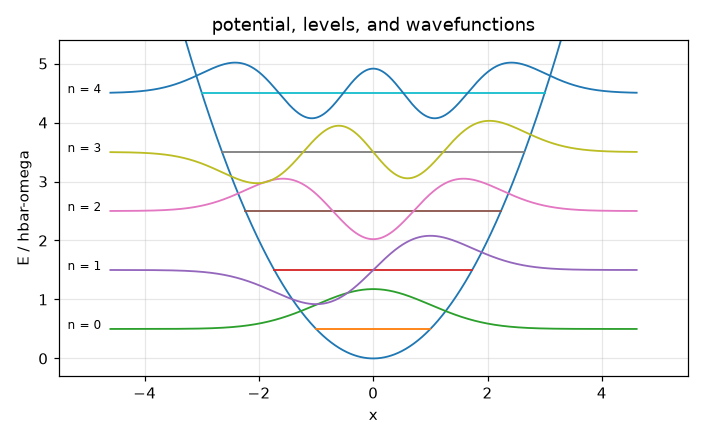

In [7]:
%%plot --title "potential, levels, and wavefunctions" --xlabel "x" --ylabel "E / hbar-omega" --grid
(define win (frame -5.5 5.5 -.3 5.4))
(plot-function win (lambda (x) (* .5 (square x))) -3.3 3.3 .01)    ; the well
(for-each
  (lambda (n)
    (let* ((e (+ n .5))
           (turning (sqrt (* 2. e))))
      (plot-line win (- turning) e turning e)                       ; the level
      (plot-function win (lambda (x) (+ e (* .9 ((psi-ho n) x))))   ; psi_n on it
                     -4.6 4.6 .01)
      (graphics-draw-text win -5.35 e (string-append "n = " (number->string n)))))
  (list 0 1 2 3 4))

Each level line is drawn between the **classical turning points**, where
$\tfrac12 x^2 = E_n$ and a classical particle would stop and turn around. Look at
what $\psi_n$ does past those ends: it is small, but not zero. The particle has a
non-zero probability of being found where a classical particle could not be at
all, because it would need negative kinetic energy there. This is *tunnelling*,
and here it is in the simplest possible system.

Now the densities on their own.

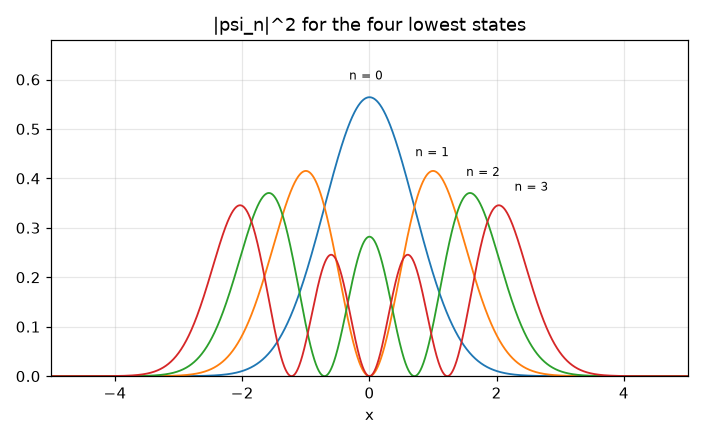

In [8]:
%%plot --title "|psi_n|^2 for the four lowest states" --xlabel "x" --grid
(define win (frame -5. 5. 0. .68))
(for-each (lambda (n)
            (plot-function win (lambda (x) (square ((psi-ho n) x))) -5. 5. .005))
          (list 0 1 2 3))
(graphics-draw-text win -.32 .60 "n = 0")     ; each label sits over
(graphics-draw-text win .72 .445 "n = 1")     ; that state's own peak
(graphics-draw-text win 1.52 .405 "n = 2")
(graphics-draw-text win 2.28 .375 "n = 3")

The ground state is a single bump at the origin -- the particle is most likely at
the bottom of the well, where a classical oscillator spends the *least* time.
That is as un-classical as it gets, and section 3.6 shows it reversing at large
$n$.

## 3.5 The uncertainty principle, by integration

Heisenberg's bound is $\Delta x\,\Delta p \ge \hbar/2$. We can just compute both
sides. By symmetry $\langle x\rangle = \langle p\rangle = 0$ for every $\psi_n$,
so $\Delta x = \sqrt{\langle x^2\rangle}$ and $\Delta p = \sqrt{\langle p^2\rangle}$,
with

$$\langle p^2 \rangle = \int \psi\,(-\hbar^2 \psi'')\,dx .$$

One practical point: build the derivative procedure *once*, outside the
integrand. `definite-integral` does not cope with a fresh `D` being constructed
on every sample.

In [9]:
(define (x2-expect n)
  (definite-integral (lambda (x) (* x x (square ((psi-ho n) x)))) -9. 9. 1e-11))

(define (p2-expect n)
  (let ((psi (psi-ho n))
        (d2psi ((expt D 2) (psi-ho n))))          ; built once, not per sample
    (definite-integral (lambda (x) (* -1 (psi x) (d2psi x))) -9. 9. 1e-11)))

(map (lambda (n)
       (list n
             'dx.dp (sqrt (* (x2-expect n) (p2-expect n)))
             'energy (* 1/2 (+ (x2-expect n) (p2-expect n)))))
     (list 0 1 2 3))

x2-expect 
p2-expect 
#|
((0 dx.dp .49999999999999994 energy .5)
 (1 dx.dp 1.4999999999999996 energy 1.4999999999999996)
 (2 dx.dp 2.500000000000004 energy 2.500000000000004)
 (3 dx.dp 3.4999999999998854 energy 3.4999999999998854))
|#

Two results in one table.

**The uncertainty product is $n + \tfrac12$.** For the ground state it is exactly
$\tfrac12 = \hbar/2$: the Gaussian does not merely satisfy Heisenberg's
inequality, it *saturates* it. No state in any system is more localized in
position and momentum at once. The zero-point energy of section 3.1 is this
bound, expressed in energy.

**The energy comes back out.** $\langle T\rangle + \langle V\rangle =
\tfrac12\langle p^2\rangle + \tfrac12\langle x^2\rangle = n + \tfrac12$, matching
the eigenvalues of section 3.2 by a completely independent route -- numerical
integration against symbolic cancellation. And since
$\langle x^2\rangle = \langle p^2\rangle$, we get
$\langle T\rangle = \langle V\rangle = \tfrac12 E_n$, the same equipartition seen
in notebook 1's classical energy plot.

## 3.6 The classical limit

A classical oscillator of energy $E$ moves slowest near its turning points, so
over time it is found there most often. Its probability density is

$$P_{\text{cl}}(x) = \frac{1}{\pi\sqrt{2E - x^2}},$$

which *peaks at the edges* -- the exact opposite of the quantum ground state.
Take $n$ large and the two come together.

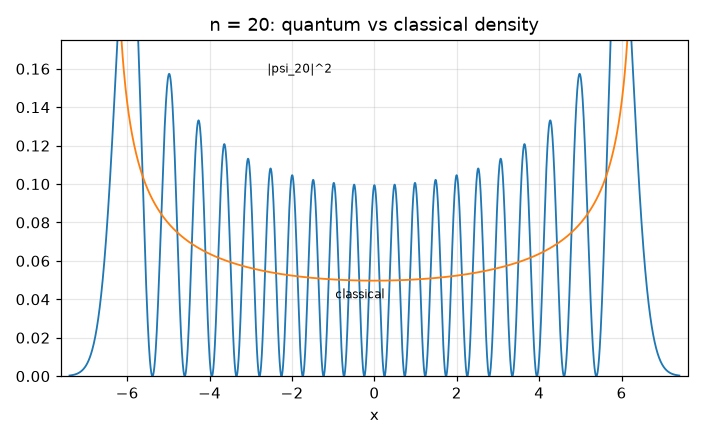

In [10]:
%%plot --title "n = 20: quantum vs classical density" --xlabel "x" --grid
(define nbig 20)
(define ebig (+ nbig .5))
(define turning (sqrt (* 2. ebig)))
(define win (frame -7.6 7.6 0. .175))
(plot-function win (lambda (x) (square ((psi-ho nbig) x))) -7.4 7.4 .006)
(plot-function win (lambda (x) (/ 1. (* pi (sqrt (- (* 2. ebig) (square x))))))
               (* turning -.995) (* turning .995) .01)
(graphics-draw-text win -2.6 .158 "|psi_20|^2")
(graphics-draw-text win -.95 .0405 "classical")

The classical curve threads through the middle of the quantum wiggles, and both
pile up at the turning points. The oscillations never go away -- there are always
$n$ nodes -- but they get finer, and any measurement that averages over a small
window cannot tell the two apart. The correspondence principle again, the same as
notebook 2's $n = 30$ box.

## What to carry forward

- $E_n = (n + \tfrac12)\hbar\omega$: **evenly spaced** levels, unlike the box.
- The ground state has energy $\hbar\omega/2$ and exactly saturates
  $\Delta x\,\Delta p = \hbar/2$.
- The wavefunction leaks past the classical turning points.
- Equal spacing invites reading $n$ as a *count*. Notebook 4 makes that literal.

Next: [operators as matrices](04-operators-and-matrices.ipynb), where the same
oscillator is solved again without ever writing down a wavefunction.